# Melbourne Street Network Analysis

Collect street network data and analyse it ready for use in modelling.

Cite OSMNX library [here](https://geoffboeing.com/publications/osmnx-complex-street-networks/)

In [5]:
import requests  # for downloading data
import os
import pickle
import datetime
import momepy

import numpy as np
import pandas as pd
import geopandas as gpd
import contextily as cx
import osmnx as ox
import networkx as nx

from zipfile import ZipFile
import matplotlib.pyplot as plt

## Load data

~First some other data so that we know the spatial extent of the area that we are using.  Use the landmarks data from the [Melbourne Open Data Portal](https://data.melbourne.vic.gov.au/People/Landmarks-and-places-of-interest-including-schools/j5vt-ppat)~

_This was unnecessary because the road network data we download are already clipped to the area of interest_

### Melbourne Boundary

Get the [municipal boundary](https://data.melbourne.vic.gov.au/Property/Municipal-boundary/ck33-yh8z) (i.e. the study area). I couldn't work out how to get this one automatically so need to download manually (it's a zip file with a shapefile, and associated files, inside).

<AxesSubplot:>

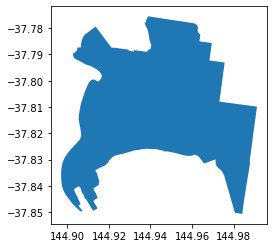

In [2]:
boundary_file = os.path.join("Municipal boundary", "geo_export_14403582-ca81-4ce2-bfcc-1421eb473132.shp")

assert os.path.exists(boundary_file), "Municipal boundary file needs downloading and extracting"

boundary = gpd.read_file(boundary_file)
boundary.plot()

### Melbourne pedestrian network

Now get the road network data. Use the [pedestrian route data](https://data.melbourne.vic.gov.au/Transport/Pedestrian-Network/4id4-tydi) that are already available. These are shared as a `zip` file so download and extract that first if needed.

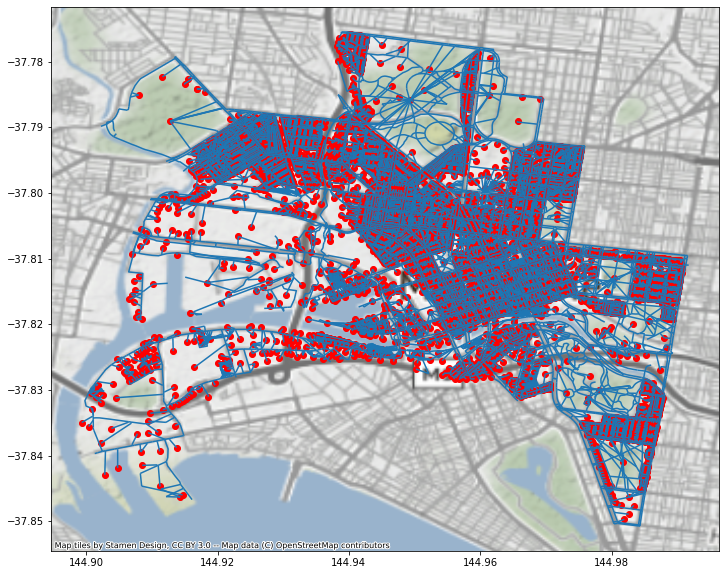

In [3]:
network_file = "Pedestrian_network.json"
property_file = "Property_centroid.json"

if not os.path.exists(network_file):
    zip_filename = "Pedestrian_Network.zip"
    print("Street network data doesn't exist, downloading ...",)
    url = "https://data.melbourne.vic.gov.au/download/4id4-tydi/application%2Fzip"
    response = requests.get(url)
    with open(zip_filename, 'wb') as f:
        f.write(response.content) 
    print("\t ... finished. Extracting zipfile ...",)
    with ZipFile(zip_filename, 'r') as zObject:
        zObject.extractall()
    # Should have two new files
    assert os.path.exists(network_file)
    assert os.path.exists(property_file)
    os.remove(zip_filename)

# Read the network
network = gpd.read_file(network_file, crs="EPSG:4326")
network = network.set_index("OBJECTID", drop=True)
network['osmid'] = network.index  # Fake an OSM ID (osmnx needs this later?)

# Read the properties
properties = gpd.read_file(property_file, crs="EPSG:4326")

# Plot
ax = network.plot(figsize=(12,10))
properties.plot(ax=ax, color='red')
cx.add_basemap(ax, crs=network.crs, zoom=12)

Create a networkx graph from the pedestrian network, adapting the [`_create_graph`](https://github.com/gboeing/osmnx/blob/3f184b8813529fefe79208057844e343dd49d0dd/osmnx/graph.py#L528) osmnx code and the networkx tutorial ['Graphs from a set of lines'](https://networkx.org/documentation/stable/auto_examples/geospatial/plot_lines.html) (which uses the `momepy` library).

In [34]:
#metadata = {
#    "created_date": str(datetime.datetime.now()),
#    #"created_with": f"OSMnx {__version__}",
#    "crs": network.crs,
#}
#G = nx.MultiDiGraph(**metadata)
G = momepy.gdf_to_nx(network, approach="primal", length="length")

if not nx.is_connected(G):
    print("Graph is not connected, pruning...")
    subgraphs = list(nx.connected_components(G))
    print(f"\t found {len(list(subgraphs))} subgraphs")
    largest_subgraph = max(subgraphs, key=len)
    print(f"\t largest subgraph has {len(largest_subgraph)} edges")
    G = G.subgraph(largest_subgraph).copy()
    assert nx.is_connected(G)

# convert graph to geodataframe
gdf_edges = ox.graph_to_gdfs(G, nodes=False)

/Users/nick/opt/anaconda3/envs/py39/lib/python3.9/site-packages/momepy/utils.py:247: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_network[length] = gdf_network.geometry.length


Graph is not connected, pruning...
	 found 3 subgraphs
	 largest subgraph has 62094 edges


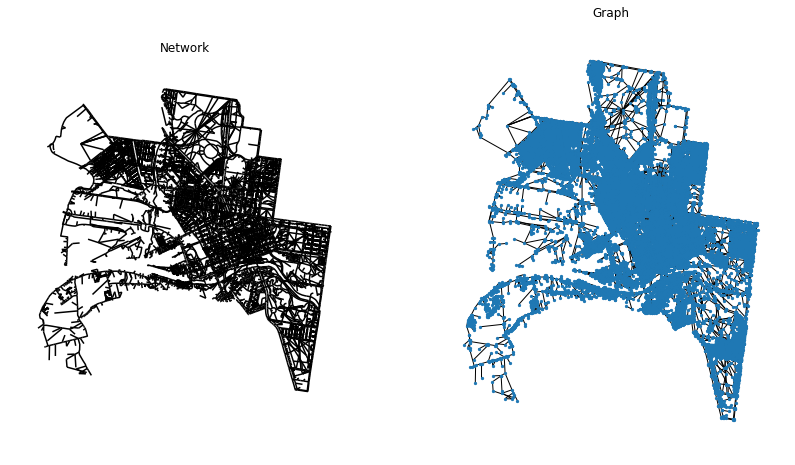

In [35]:
positions = {n: [n[0], n[1]] for n in list(G.nodes)}

# Plot
f, ax = plt.subplots(1, 2, figsize=(14, 8), sharex=True, sharey=True)
network.plot(color="k", ax=ax[0])
for i, facet in enumerate(ax):
    facet.set_title(("Network", "Graph")[i])
    facet.axis("off")
nx.draw(G, positions, ax=ax[1], node_size=5)

### OSM Network

As an alternative, get the network directly from OSM

#### Max speed

Plot the max speed (mostly for interest, seems like most roads don't have a max speed)

## Calculate space syntax statistics

In [36]:
basic_stats = ox.basic_stats(G)
basic_stats

ValueError: max() arg is an empty sequence

### Centrality indicators

https://github.com/gboeing/osmnx-examples/blob/eaf8b989d168098d73f8f13ca1a356e4a2cf7189/notebooks/06-stats-indicators-centrality.ipynb


#### Node Betweenneess Centrality

This isn't so useful, but a good start (based on [this example](https://github.com/gboeing/osmnx-examples/blob/eaf8b989d168098d73f8f13ca1a356e4a2cf7189/notebooks/06-stats-indicators-centrality.ipynb)). I calculate edge betweenness centrality (more useful) later.

In [37]:
# calculate betweenness with a digraph of G (ie, no parallel edges)
if os.path.exists('bc.pickle'):
    print("Loading betweenness from pickle")
    bc = pickle.load(open('bc.pickle', 'rb'))
else:
    print("(Re) calculating betweenneess centrality, this may take an hour or two")
    bc = nx.betweenness_centrality(ox.get_digraph(G), weight="length")
    pickle.dump(bc, open('bc.pickle', 'wb'))

(Re) calculating betweenneess centrality, this may take an hour or two


Which node has the highest betweenness?

In [38]:
max_node, max_bc = max(bc.items(), key=lambda x: x[1])
print(f"Node {max_node} has the highest betweenness, with {round(max_bc*100,2)}% of all shortest paths running through it") 

Node (144.9592514684, -37.8063995735) has the highest betweenness, with 18.95% of all shortest paths running through it


Plot the node with the highest betweenness:

TypeError: Must pass list-like as `names`.

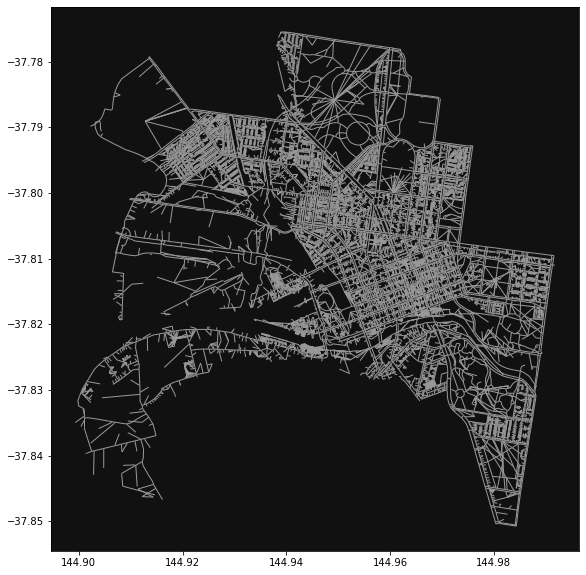

In [40]:
nc = ["r" if node == max_node else "w" for node in G.nodes]
ns = [80 if node == max_node else 15 for node in G.nodes]
fig, ax = ox.plot_graph(G, node_size=ns, node_color=nc, node_zorder=2, figsize=(12,10))

Plot betweenness centrality of all nodes

TypeError: Must pass list-like as `names`.

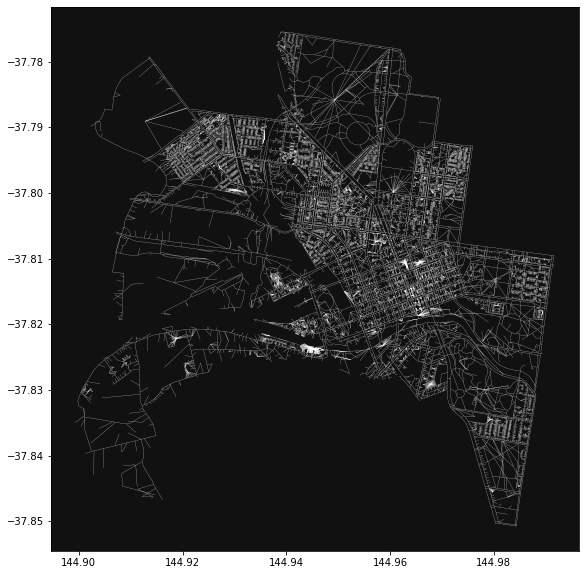

In [41]:
# add the betweenness centraliy values as new node attributes, then plot
nx.set_node_attributes(G, bc, "bc")
nc = ox.plot.get_node_colors_by_attr(G, "bc", cmap="plasma")
fig, ax = ox.plot_graph(
    G,
    node_color=nc,
    node_size=30,
    node_zorder=2,
    edge_linewidth=0.2,
    edge_color="w",
    figsize=(12,10),
)

#### Edge Betweenneess Centrality

One of the centrality measures available in NetworkX (see [Network X centrality docs](https://networkx.org/documentation/stable/reference/algorithms/centrality.html)).

In [42]:
# calculate betweenness with a digraph of G (ie, no parallel edges)
if os.path.exists('ebc.pickle'):
    print("Loading betweenness from pickle")
    ebc = pickle.load(open('ebc.pickle', 'rb'))
else:
    print("(Re) calculating edge betweenneess centrality, this may take an hour or two")
    ebc = nx.edge_betweenness_centrality(ox.get_digraph(G), weight="length")
    pickle.dump(bc, open('ebc.pickle', 'wb'))

(Re) calculating edge betweenneess centrality, this may take an hour or two


Link the edge betweenness back to the original edges geodataframe

In [43]:
gdf_edges['betweenness'] = gdf_edges.index.map(ebc)

The distribution has a very long tail:

<AxesSubplot:>

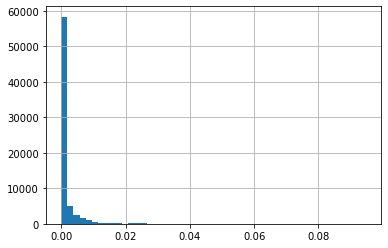

In [45]:
gdf_edges['betweenness'].hist(bins=50)

Neeed to normalise. Log doesn't help much as there are some edges with betweeness=0, and adding 1 to all values before logging still results in quite a skewed distribution. Use square root instead

<AxesSubplot:>

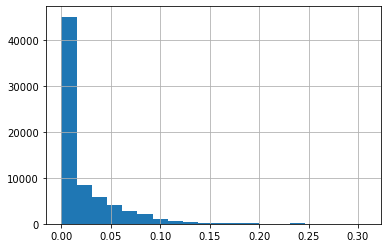

In [58]:
np.sqrt(gdf_edges['betweenness']).hist(bins=20)

<AxesSubplot:>

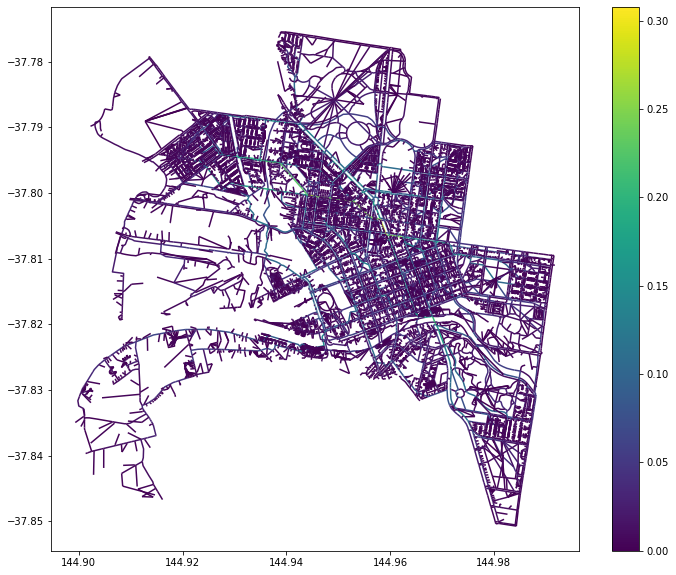

In [59]:
gdf_edges['betweenness_sqrt'] = np.sqrt(gdf_edges['betweenness'])
gdf_edges.plot(column='betweenness_sqrt', figsize=(12,10), legend=True)

Write this out (useful for a GIS with a GUI)

In [63]:
#gdf_edges.reset_index().loc[:,['u','v','betweenness','betweenness_sqrt', 'geometry']].to_file("gdf_edges.shp")
gdf_edges.reset_index().loc[:,['betweenness','betweenness_sqrt', 'geometry']].to_file("gdf_edges.shp")

/var/folders/bv/vmwq8bq15fnbby8ds2nqvql40000gn/T/ipykernel_12534/3117698116.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_edges.reset_index().loc[:,['betweenness','betweenness_sqrt', 'geometry']].to_file("gdf_edges.shp")
